# Task 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv('diabetes.csv')

## 1.1 — Shape and First Rows

In [3]:
# prints the dimensions as (rows, columns)
print('Shape:', df.shape)

# displays the first 5 rows
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1.2 — Missing Values and Suspicious Zeros

In [4]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# Zeros here mean missing data
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts in physiologically impossible columns:')
print((df[zero_cols] == 0).sum())

Zero counts in physiologically impossible columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 1.3 — Class Distribution

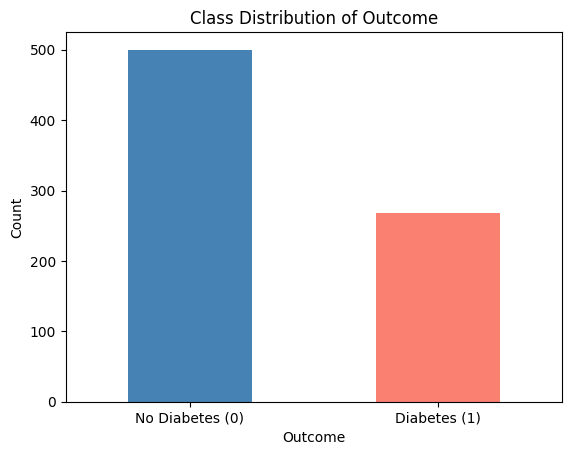

In [6]:
# Class distribuition
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution of Outcome')
plt.show()

**Class Distribution — Observations:**

The dataset contains 500 negative cases (no diabetes) and 268 positive cases (diabetes), giving a roughly 65/35 split. The classes are **moderately imbalanced** — there are nearly twice as many non-diabetic patients as diabetic ones. This means a naive classifier that always predicts "no diabetes" would achieve ~65% accuracy without learning anything useful. As a result, **F1 score** is a more meaningful metric than accuracy alone for this problem, as it accounts for the model's ability to correctly identify the minority (diabetic) class.

## 1.4 — Feature Distributions

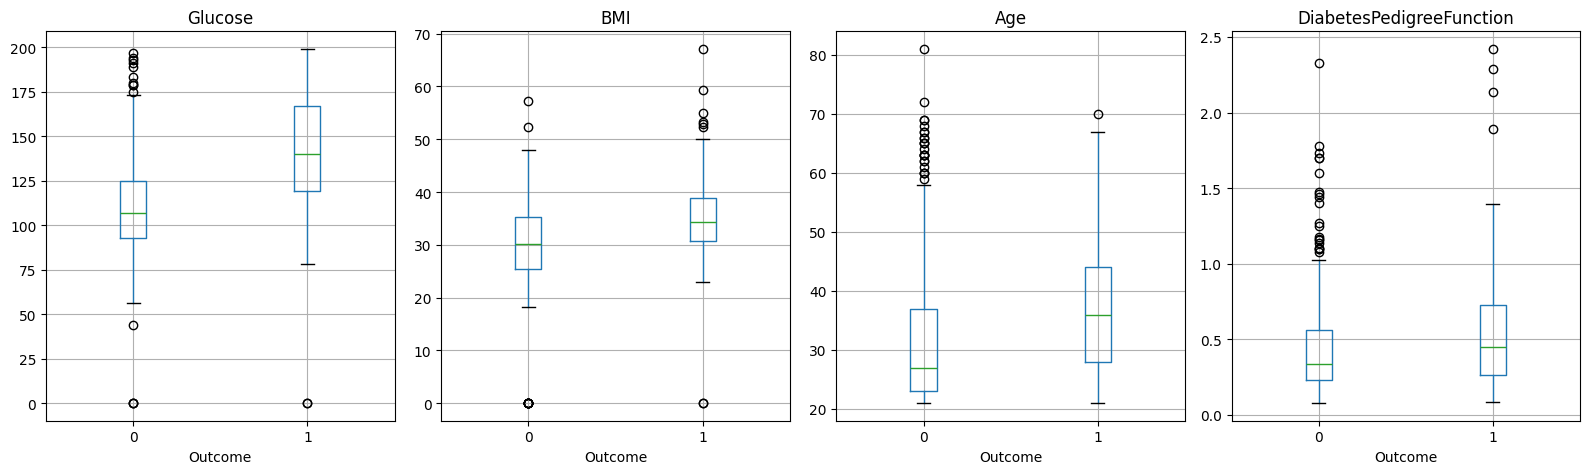

In [7]:
features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feature in zip(axes, features):
    df.boxplot(column=feature, by='Outcome', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Outcome')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 1.5 — EDA Summary

The dataset contains 768 records with 9 features and no genuine `NaN` values, however several columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contain zeros that are physiologically impossible, indicating missing data encoded as zero — `Insulin` and `SkinThickness` are the most affected columns. The target variable (`Outcome`) is moderately imbalanced, with approximately 65% negative and 35% positive cases, which must be accounted for during modelling and evaluation. The boxplots reveal that `Glucose` shows the strongest separation between classes, making it likely the most informative feature, followed by `BMI` and `Age`. `DiabetesPedigreeFunction` shows some separation but with considerable overlap and outliers, suggesting it may be a weaker predictor on its own.

# Task 2

## 2.1 — Addressing Data Quality Issues

The zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are physiologically impossible and represent missing data. We replace them with `NaN` and then impute using the **median** of each column. The median is preferred over the mean here because some of these columns (particularly `Insulin`) have skewed distributions, and the median is more robust to outliers.

In [8]:
# Replace impossible zeros with NaN, then impute with column median
df[zero_cols] = df[zero_cols].replace(0, pd.NA)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

print('Zero counts after imputation:')
print((df[zero_cols] == 0).sum())

Zero counts after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 2.2 — Feature Scaling

We apply **StandardScaler** to all features, which transforms each column to have a mean of 0 and a standard deviation of 1. This is important for distance-based models (KNN, SVM) which are sensitive to the scale of features — without scaling, a column like `Insulin` (values in the hundreds) would dominate over `DiabetesPedigreeFunction` (values near 0). Tree-based models like Random Forest don't strictly need scaling, but it doesn't hurt.

In [9]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Outcome')
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled feature means (should be ~0):', X_scaled.mean(axis=0).round(2))
print('Scaled feature stds  (should be ~1):', X_scaled.std(axis=0).round(2))

Scaled feature means (should be ~0): [-0.  0.  0. -0.  0.  0.  0.  0.]
Scaled feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 2.3 — Train / Validation / Test Split (60/20/20)

We do a two-step split to get three sets:
1. Split `X_scaled`/`y` into 80% temp and 20% test
2. Split the 80% temp into 75% train and 25% val — which gives us 60/20/20 overall

`stratify=y` ensures each split preserves the same 65/35 class ratio as the full dataset. The random seed is your student ID.

In [10]:
from sklearn.model_selection import train_test_split

SEED = 418763

# Step 1: split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)

# Step 2: split the remaining 80% into train (75%) and val (25%) → 60/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED
)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 460 | Val: 154 | Test: 154


# Task 3

## 3A K-Nearest Neighbours

KNN is a reasonable choice here because the dataset is relatively small (460 training samples) and has numeric features that are now scaled — KNN relies on distance between points so scaling is essential. It's a non-parametric model that makes no assumptions about the data distribution, which suits this dataset where the decision boundary is unlikely to be linear.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

knn_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
knn_search.fit(X_train, y_train)

print('Best params:', knn_search.best_params_)
print('Best CV F1: ', round(knn_search.best_score_, 4))

Best params: {'n_neighbors': 7, 'weights': 'distance'}
Best CV F1:  0.6334


## 3B Logistic Regression

Logistic Regression is a good baseline classifier for binary problems. It's fast, interpretable, and works well when there is a roughly linear relationship between the features and the log-odds of the outcome. `Glucose` and `BMI` showed strong linear-looking separation in the EDA, making this a reasonable choice. The regularisation parameter `C` controls overfitting and is worth tuning.

In [12]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED),
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
lr_search.fit(X_train, y_train)

print('Best params:', lr_search.best_params_)
print('Best CV F1: ', round(lr_search.best_score_, 4))

Best params: {'C': 10, 'solver': 'lbfgs'}
Best CV F1:  0.6419


## 3C Random Forest

Random Forest is an ensemble of decision trees that reduces overfitting by averaging many trees trained on random subsets of data and features. It handles non-linear relationships well and is generally robust without much tuning. It also naturally handles the moderate class imbalance reasonably well. We tune `n_estimators` (number of trees) and `max_depth` (how deep each tree grows).

In [13]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('Best params:', rf_search.best_params_)
print('Best CV F1: ', round(rf_search.best_score_, 4))

Best params: {'max_depth': 10, 'n_estimators': 100}
Best CV F1:  0.6654


# Task 4

In [14]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    'KNN': knn_search.best_estimator_,
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_val, y_pred), 4),
        'F1 Score': round(f1_score(y_val, y_pred), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

                     Accuracy  F1 Score
Model                                  
KNN                    0.7597    0.6726
Logistic Regression    0.7922    0.7037
Random Forest          0.7273    0.6182


## 4.1 — Validation Set Comparison Summary

Logistic Regression performs best on the validation set with an accuracy of **0.7922** and an F1 score of **0.7037**, outperforming both KNN (F1: 0.6726) and Random Forest (F1: 0.6182). 

- This result is consistent with the EDA findings: `Glucose` and `BMI` showed strong, roughly linear separation between classes, which plays directly to Logistic Regression's strengths. 

- The dataset is also relatively small (460 training samples), which limits the advantage of more complex models like Random Forest that typically need more data to generalise well. 

- KNN performs reasonably but is sensitive to the moderate class imbalance and high-dimensional feature space. Given that F1 is the more meaningful metric here due to the 65/35 class split, Logistic Regression is the clear choice to take forward.

# Task 5

## 5.1 — Final Model Selection

**Selected model: Logistic Regression**

Logistic Regression achieved the highest validation F1 score (0.7037) and accuracy (0.7922) of the three candidates. It is the most appropriate choice for this dataset given the roughly linear separability observed in the EDA — particularly for `Glucose` and `BMI` — and the relatively small training set size where simpler models tend to generalise better than more complex ensembles.

## 5.2 — Retrain on Train + Validation Combined

In [15]:
import numpy as np

# Combine train and validation sets
X_trainval = np.concatenate([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# Retrain using the best hyperparameters found in Task 3
best_params = lr_search.best_params_
final_model = LogisticRegression(max_iter=1000, random_state=SEED, **best_params)
final_model.fit(X_trainval, y_trainval)

print('Final model trained on', X_trainval.shape[0], 'samples')
print('Best params used:', best_params)

Final model trained on 614 samples
Best params used: {'C': 10, 'solver': 'lbfgs'}


## 5.3 — Classification Report on Test Set

In [16]:
from sklearn.metrics import classification_report

y_test_pred = final_model.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.75      0.91      0.82       100
    Diabetes       0.72      0.43      0.53        54

    accuracy                           0.74       154
   macro avg       0.73      0.67      0.68       154
weighted avg       0.74      0.74      0.72       154



## 5.4 — Confusion Matrix Heatmap

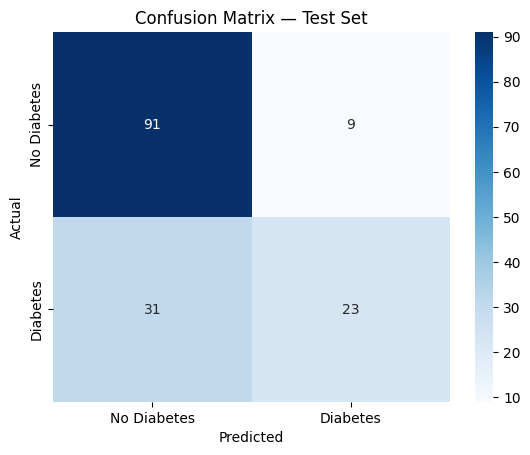

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.show()

## 5.5 — Final Results Interpretation

The final Logistic Regression model achieves **74% accuracy** and an F1 score of **0.53** for the diabetic class on the held-out test set. The model performs well on the majority class — correctly identifying 91 of 100 non-diabetic patients (recall 0.91) — but struggles significantly with the minority class, correctly identifying only 23 of 54 diabetic patients (recall 0.43). The dominant error pattern is **false negatives**: 31 diabetic patients were incorrectly predicted as non-diabetic. This asymmetry is consistent with the class imbalance in the dataset — the model is biased toward predicting the majority class.

This model would **not** be suitable for deployment in a clinical setting in its current form. A recall of 43% for the diabetic class means more than half of all diabetic patients would go undetected, which carries serious health risks. In a clinical context, **false negatives are far more costly than false positives** — missing a diabetes diagnosis can lead to untreated disease progression, while a false positive results in further (confirmatory) testing. To improve clinical viability, the decision threshold should be lowered to prioritise recall for the positive class, or class weights should be incorporated during training to penalise false negatives more heavily.